In [ ]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ROOT = Path("kaggle-dataset")
IMAGE_ROOT = ROOT / "image_features" / "image_features"

TEST_ROOT = Path("new_test")
TEST_IMAGE_ROOT = TEST_ROOT / "image_features" / "image_features"

MODALITIES = ["ax_t1", "ax_t1c", "ax_t2", "ax_t2f"]

Device: cuda


In [ ]:
def load_json_dict(filename, base_root=ROOT):
    with open(base_root / filename, "r") as f:
        return json.load(f)


def load_split_tables(split, base_root=ROOT):
    # Support both old format: <root>/clinical_information/<split>_patient_info.csv
    # and new format: <root>/clinical_information/<split>/<split>_patient_info.csv
    clinical_old = base_root / "clinical_information" / f"{split}_patient_info.csv"
    clinical_new = base_root / "clinical_information" / split / f"{split}_patient_info.csv"
    raw_old = base_root / "original_raw_report" / f"{split}_patient_info.csv"
    raw_new = base_root / "original_raw_report" / split / f"{split}_patient_info.csv"

    clinical_path = clinical_old if clinical_old.exists() else clinical_new
    raw_path = raw_old if raw_old.exists() else raw_new

    clinical = pd.read_csv(clinical_path)
    raw_report = pd.read_csv(raw_path)

    clinical["case_id"] = clinical["case_id"].astype(str)
    raw_report["case_id"] = raw_report["case_id"].astype(str)

    merged = clinical.merge(raw_report, on="case_id", how="left")

    # Radiomics (4 modality tables -> wide format)
    rad_frames = []
    for mod in MODALITIES:
        rad = pd.read_csv(base_root / "radiomics_info" / split / f"{mod}_radiomics_{split}.csv")
        rad["case_id"] = rad["case_id"].astype(str)

        drop_cols = [c for c in ["sex", "age", "modality"] if c in rad.columns]
        rad = rad.drop(columns=drop_cols)

        rename_map = {c: f"{mod}__{c}" for c in rad.columns if c != "case_id"}
        rad = rad.rename(columns=rename_map)
        rad_frames.append(rad)

    rad_wide = rad_frames[0]
    for i in range(1, len(rad_frames)):
        rad_wide = rad_wide.merge(rad_frames[i], on="case_id", how="outer")

    merged = merged.merge(rad_wide, on="case_id", how="left")

    return merged


def load_labels_from_json(filename, base_root=ROOT):
    data = load_json_dict(filename, base_root=base_root)
    rows = []
    for case_id, info in data.items():
        rows.append({"case_id": str(case_id), "Overall_class": info.get("Overall_class")})
    return pd.DataFrame(rows)


def extract_image_features(case_ids, image_root=IMAGE_ROOT):
    # Per modality: 2048-d embedding + 1 presence flag, concatenated across 4 modalities.
    out = []
    for cid in case_ids:
        case_block = []
        case_dir = image_root / str(cid)
        for mod in MODALITIES:
            p = case_dir / mod / "image.npy"
            if p.exists():
                arr = np.load(p).astype(np.float32).reshape(-1)
                if arr.shape[0] != 2048:
                    arr = np.resize(arr, 2048).astype(np.float32)
                flag = np.array([1.0], dtype=np.float32)
            else:
                arr = np.zeros(2048, dtype=np.float32)
                flag = np.array([0.0], dtype=np.float32)
            case_block.append(np.concatenate([arr, flag]))
        out.append(np.concatenate(case_block))
    return np.vstack(out).astype(np.float32)


train_df = load_split_tables("train", base_root=ROOT).merge(
    load_labels_from_json("train.json", base_root=ROOT), on="case_id", how="left"
 )
val_df = load_split_tables("val", base_root=ROOT).merge(
    load_labels_from_json("val.json", base_root=ROOT), on="case_id", how="left"
 )

# Use new test set published by course staff to avoid case-id leakage risk.
test_df = load_split_tables("test", base_root=TEST_ROOT)

print("Shapes:", train_df.shape, val_df.shape, test_df.shape)
print("Train class distribution:")
print(train_df["Overall_class"].value_counts())

Shapes: (1983, 30) (283, 30) (378, 29)
Train class distribution:
Overall_class
Glioma                                     924
Meningioma                                 728
Brain Metastase Tumour                     252
Tumors of the sellar region                 56
Pineal tumour and Choroid plexus tumour     23
Name: count, dtype: int64


In [ ]:
def prepare_tabular_and_text(train_df, val_df, test_df):
    feature_cols = [c for c in train_df.columns if c not in ["case_id", "Overall_class", "raw_report"]]

    # Identify categorical and numeric columns from train split.
    categorical_cols = [c for c in feature_cols if train_df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    # Build tabular features by one-hot encoding categoricals and median-imputing numerics.
    X_train_num = train_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")
    X_val_num = val_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")
    X_test_num = test_df[numeric_cols].copy().apply(pd.to_numeric, errors="coerce")

    if len(numeric_cols) > 0:
        medians = X_train_num.median(numeric_only=True)
        X_train_num = X_train_num.fillna(medians)
        X_val_num = X_val_num.fillna(medians)
        X_test_num = X_test_num.fillna(medians)

        scaler_tab = StandardScaler()
        X_train_num_s = scaler_tab.fit_transform(X_train_num).astype(np.float32)
        X_val_num_s = scaler_tab.transform(X_val_num).astype(np.float32)
        X_test_num_s = scaler_tab.transform(X_test_num).astype(np.float32)
    else:
        # Keep a 2D empty block so concatenation logic stays uniform.
        X_train_num_s = np.zeros((len(train_df), 0), dtype=np.float32)
        X_val_num_s = np.zeros((len(val_df), 0), dtype=np.float32)
        X_test_num_s = np.zeros((len(test_df), 0), dtype=np.float32)

    if len(categorical_cols) > 0:
        X_train_cat = pd.get_dummies(train_df[categorical_cols].fillna("missing").astype(str), drop_first=False)
        X_val_cat = pd.get_dummies(val_df[categorical_cols].fillna("missing").astype(str), drop_first=False)
        X_test_cat = pd.get_dummies(test_df[categorical_cols].fillna("missing").astype(str), drop_first=False)

        X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)
        X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

        X_train_cat_arr = X_train_cat.values.astype(np.float32)
        X_val_cat_arr = X_val_cat.values.astype(np.float32)
        X_test_cat_arr = X_test_cat.values.astype(np.float32)
    else:
        # If no categorical columns exist, use empty 2D arrays.
        X_train_cat_arr = np.zeros((len(train_df), 0), dtype=np.float32)
        X_val_cat_arr = np.zeros((len(val_df), 0), dtype=np.float32)
        X_test_cat_arr = np.zeros((len(test_df), 0), dtype=np.float32)

    X_train_tab = np.hstack([X_train_num_s, X_train_cat_arr])
    X_val_tab = np.hstack([X_val_num_s, X_val_cat_arr])
    X_test_tab = np.hstack([X_test_num_s, X_test_cat_arr])

    # Text features from raw report findings
    tfidf = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=600,
        min_df=2
    )

    train_text = train_df["raw_report"].fillna("").astype(str).values
    val_text = val_df["raw_report"].fillna("").astype(str).values
    test_text = test_df["raw_report"].fillna("").astype(str).values

    X_train_text = tfidf.fit_transform(train_text).toarray().astype(np.float32)
    X_val_text = tfidf.transform(val_text).toarray().astype(np.float32)
    X_test_text = tfidf.transform(test_text).toarray().astype(np.float32)

    return X_train_tab, X_val_tab, X_test_tab, X_train_text, X_val_text, X_test_text, tfidf


X_train_tab, X_val_tab, X_test_tab, X_train_text, X_val_text, X_test_text, tfidf_model = prepare_tabular_and_text(train_df, val_df, test_df)

X_train_img = extract_image_features(train_df["case_id"].tolist(), image_root=IMAGE_ROOT)
X_val_img = extract_image_features(val_df["case_id"].tolist(), image_root=IMAGE_ROOT)
X_test_img = extract_image_features(test_df["case_id"].tolist(), image_root=TEST_IMAGE_ROOT)

scaler_img = StandardScaler()
X_train_img = scaler_img.fit_transform(X_train_img).astype(np.float32)
X_val_img = scaler_img.transform(X_val_img).astype(np.float32)
X_test_img = scaler_img.transform(X_test_img).astype(np.float32)

# Concatenate all modality groups for DNN input
X_train = np.hstack([X_train_tab, X_train_text, X_train_img]).astype(np.float32)
X_val = np.hstack([X_val_tab, X_val_text, X_val_img]).astype(np.float32)
X_test = np.hstack([X_test_tab, X_test_text, X_test_img]).astype(np.float32)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df["Overall_class"])
y_val = label_encoder.transform(val_df["Overall_class"])

print("Feature shape (train/val/test):", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", list(label_encoder.classes_))

# Track group indices for ablation / permutation analysis
group_slices = {}
start = 0
group_slices["tabular"] = (start, start + X_train_tab.shape[1])
start += X_train_tab.shape[1]
group_slices["text"] = (start, start + X_train_text.shape[1])
start += X_train_text.shape[1]
group_slices["image_deep"] = (start, start + X_train_img.shape[1])
print("Group slices:", group_slices)

Feature shape (train/val/test): (1983, 9422) (283, 9422) (378, 9422)
Classes: ['Brain Metastase Tumour', 'Glioma', 'Meningioma', 'Pineal tumour and Choroid plexus tumour', 'Tumors of the sellar region']
Group slices: {'tabular': (0, 626), 'text': (626, 1226), 'image_deep': (1226, 9422)}


In [ ]:
class MultiModalMLP(nn.Module):
    def __init__(self, group_dims, num_classes, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.group_dims = list(group_dims)
        self.branches = nn.ModuleList()
        self.active_dims = []
        branch_out_dims = []

        for dim in self.group_dims:
            if dim > 0:
                self.branches.append(nn.Sequential(
                    nn.Linear(dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ))
                self.active_dims.append(dim)
                branch_out_dims.append(hidden_dim)

        fused_dim = int(sum(branch_out_dims))
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        parts = []
        start = 0
        branch_idx = 0
        for dim in self.group_dims:
            if dim <= 0:
                continue
            part = x[:, start:start + dim]
            start += dim
            parts.append(self.branches[branch_idx](part))
            branch_idx += 1

        fused = torch.cat(parts, dim=1) if len(parts) > 1 else parts[0]
        return self.head(fused)


def make_loader(X, y=None, batch_size=64, shuffle=False, balanced=False):
    X = np.nan_to_num(np.asarray(X, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(Xt)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    yt = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(Xt, yt)

    if balanced:
        class_counts = np.bincount(y)
        sample_weights = 1.0 / class_counts[y]
        sampler = WeightedRandomSampler(
            weights=torch.as_tensor(sample_weights, dtype=torch.double),
            num_samples=len(sample_weights),
            replacement=True,
        )
        return DataLoader(ds, batch_size=batch_size, sampler=sampler)

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate_model(model, loader):
    model.eval()
    probs_all, preds_all, y_all = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            probs_all.append(probs)
            preds_all.append(preds)
            y_all.append(yb.numpy())

    y_true = np.concatenate(y_all)
    y_pred = np.concatenate(preds_all)
    y_prob = np.concatenate(probs_all)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }


def train_with_early_stopping(model, train_loader, val_loader, lr=5e-4, max_epochs=80, patience=12):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    history = {"train_loss": [], "val_f1_weighted": [], "val_f1_macro": []}

    best_state = None
    best_val = -1.0
    best_epoch = -1
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics["f1_macro"])

        history["train_loss"].append(train_loss)
        history["val_f1_weighted"].append(val_metrics["f1_weighted"] )
        history["val_f1_macro"].append(val_metrics["f1_macro"] )

        improved = val_metrics["f1_macro"] > best_val
        if improved:
            best_val = val_metrics["f1_macro"]
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d} | train_loss={train_loss:.4f} "
                f"| val_f1_weighted={val_metrics['f1_weighted']:.4f} "
                f"| val_f1_macro={val_metrics['f1_macro']:.4f} "
                f"| lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch={best_epoch}, best val macro F1={best_val:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch, best_val

Epoch 001 | train_loss=0.8040 | val_f1_weighted=0.0341 | val_f1_macro=0.0747 | lr=5.00e-04
Epoch 005 | train_loss=0.0772 | val_f1_weighted=0.4654 | val_f1_macro=0.5172 | lr=5.00e-04
Epoch 010 | train_loss=0.0330 | val_f1_weighted=0.7354 | val_f1_macro=0.6397 | lr=5.00e-04
Epoch 015 | train_loss=0.0181 | val_f1_weighted=0.7814 | val_f1_macro=0.6754 | lr=5.00e-04
Epoch 020 | train_loss=0.0133 | val_f1_weighted=0.8058 | val_f1_macro=0.6877 | lr=5.00e-04
Epoch 025 | train_loss=0.0069 | val_f1_weighted=0.8370 | val_f1_macro=0.7104 | lr=2.50e-04
Epoch 030 | train_loss=0.0061 | val_f1_weighted=0.8241 | val_f1_macro=0.7367 | lr=1.25e-04
Epoch 035 | train_loss=0.0041 | val_f1_weighted=0.8340 | val_f1_macro=0.7210 | lr=6.25e-05
Epoch 040 | train_loss=0.0054 | val_f1_weighted=0.8380 | val_f1_macro=0.7220 | lr=3.13e-05
Epoch 045 | train_loss=0.0040 | val_f1_weighted=0.8445 | val_f1_macro=0.7573 | lr=3.13e-05
Epoch 050 | train_loss=0.0040 | val_f1_weighted=0.8445 | val_f1_macro=0.7573 | lr=1.56e-05

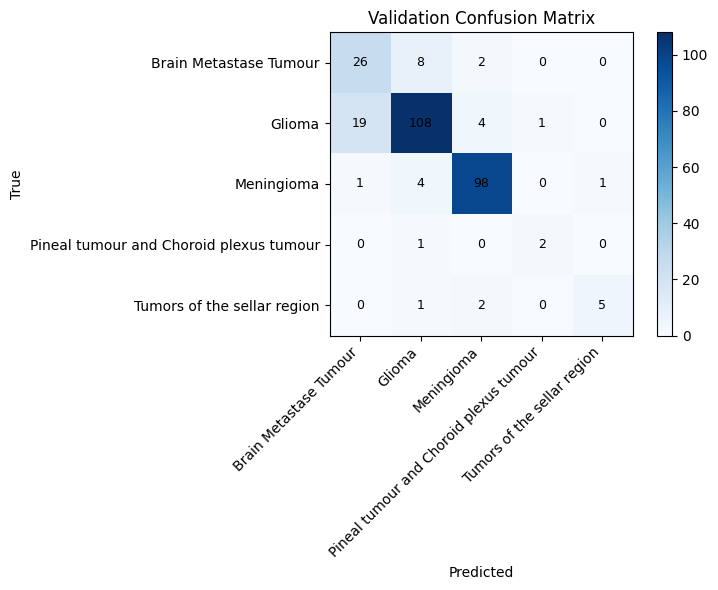

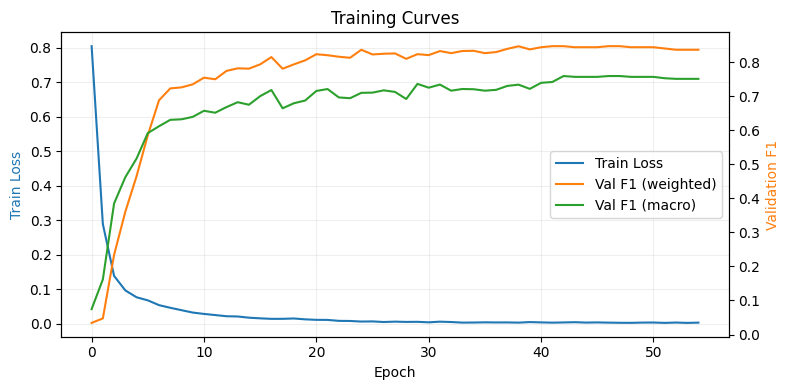

In [ ]:
train_loader = make_loader(X_train, y_train, batch_size=64, balanced=True)
val_loader = make_loader(X_val, y_val, batch_size=256, shuffle=False)

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)


model = MultiModalMLP(
    group_dims=(X_train_tab.shape[1], X_train_text.shape[1], X_train_img.shape[1]),
    num_classes=len(label_encoder.classes_),
    hidden_dim=128,
    dropout=0.3,
).to(device)

model, history, best_epoch, best_val = train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    lr=5e-4,
    max_epochs=80,
    patience=12,
)

print(f"Best epoch: {best_epoch}, Best val macro F1: {best_val:.4f}")

val_metrics = evaluate_model(model, val_loader)
print("Validation weighted F1:", round(val_metrics["f1_weighted"], 4))
print("Validation macro F1:", round(val_metrics["f1_macro"], 4))

print("\nClassification report (validation):")
print(
    classification_report(
        val_metrics["y_true"],
        val_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4
    )
)

cm = confusion_matrix(val_metrics["y_true"], val_metrics["y_pred"])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Validation Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(np.arange(len(label_encoder.classes_)))
ax.set_yticks(np.arange(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(label_encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
line1 = ax1.plot(history["train_loss"], label="Train Loss", color="tab:blue")
line2 = ax2.plot(history["val_f1_weighted"], label="Val F1 (weighted)", color="tab:orange")
line3 = ax2.plot(history["val_f1_macro"], label="Val F1 (macro)", color="tab:green")

ax1.set_title("Training Curves")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color="tab:blue")
ax2.set_ylabel("Validation F1", color="tab:orange")
ax1.grid(alpha=0.2)

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")
plt.tight_layout()
plt.show()

In [ ]:
def predict_from_array(model, X, batch_size=256):
    loader = make_loader(X, y=None, batch_size=batch_size, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)

def ablation_score(model, X_val, y_val, group_slices, average="weighted"):
    base_preds = predict_from_array(model, X_val)
    base = f1_score(y_val, base_preds, average=average)

    rows = []
    for g, (l, r) in group_slices.items():
        X_mod = X_val.copy()
        X_mod[:, l:r] = 0.0
        p = predict_from_array(model, X_mod)
        score = f1_score(y_val, p, average=average)
        rows.append({"group": g, "f1": score, "drop_from_base": base - score})

    out = pd.DataFrame(rows).sort_values("drop_from_base", ascending=False)
    return base, out


def permutation_group_importance(model, X_val, y_val, group_slices, n_repeats=3, average="weighted"):
    rng = np.random.default_rng(SEED)
    base_preds = predict_from_array(model, X_val)
    base = f1_score(y_val, base_preds, average=average)

    records = []
    for g, (l, r) in group_slices.items():
        drops = []
        for _ in range(n_repeats):
            X_perm = X_val.copy()
            perm_idx = rng.permutation(X_perm.shape[0])
            X_perm[:, l:r] = X_perm[perm_idx, l:r]
            p = predict_from_array(model, X_perm)
            s = f1_score(y_val, p, average=average)
            drops.append(base - s)
        records.append({
            "group": g,
            "mean_drop": float(np.mean(drops)),
            "std_drop": float(np.std(drops))
        })

    out = pd.DataFrame(records).sort_values("mean_drop", ascending=False)
    return base, out


base_f1, ablation_df = ablation_score(model, X_val, y_val, group_slices, average="weighted")
print("Base validation weighted F1:", round(base_f1, 4))
print("\nAblation result (higher drop = more important):")
display(ablation_df)

perm_base, perm_df = permutation_group_importance(model, X_val, y_val, group_slices, n_repeats=3, average="weighted")
print("\nPermutation group importance (weighted F1 drop):")
display(perm_df)



Base validation weighted F1: 0.8476

Ablation result (higher drop = more important):


,group,f1,drop_from_base
1,text,0.385179,0.462391
0,tabular,0.824199,0.023370
2,image_deep,0.836036,0.011534



Permutation group importance (weighted F1 drop):


,group,mean_drop,std_drop
1,text,0.437631,0.021894
2,image_deep,0.054508,0.009220
0,tabular,0.032520,0.001238


In [ ]:
test_preds_idx = predict_from_array(model, X_test)
test_preds_label = label_encoder.inverse_transform(test_preds_idx)

submission = pd.DataFrame({
    "case_id": test_df["case_id"].astype(int),
    "Overall_class": test_preds_label
}).sort_values("case_id").reset_index(drop=True)

sample_sub = pd.read_csv(TEST_ROOT / "sample_submission.csv")
submission = sample_sub[["case_id"]].merge(submission, on="case_id", how="left")

out_path = TEST_ROOT / "sample_submission_dnn.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
print(submission.head(10))
print("\nClass distribution in prediction:")
print(submission["Overall_class"].value_counts(dropna=False))

Saved: /content/new_test/sample_submission_dnn.csv
    case_id                Overall_class
0  10498325                       Glioma
1  10508271                   Meningioma
2  10877188                       Glioma
3  11175873                   Meningioma
4  11209618       Brain Metastase Tumour
5  11333692                       Glioma
6  11521045                       Glioma
7  11775475                       Glioma
8  12255903  Tumors of the sellar region
9  12568593                       Glioma

Class distribution in prediction:
Overall_class
Glioma                                     152
Meningioma                                 125
Brain Metastase Tumour                      64
Tumors of the sellar region                 22
Pineal tumour and Choroid plexus tumour     15
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    roc_auc_score, log_loss,
    cohen_kappa_score, matthews_corrcoef,
    classification_report, confusion_matrix,
)

# ---- Reuse outputs from the existing evaluator ----
_m = evaluate_model(model, val_loader)
y_true = _m["y_true"]
y_pred = _m["y_pred"]
y_prob = _m["y_prob"]
classes = list(label_encoder.classes_)
n_classes = len(classes)
all_labels = list(range(n_classes))

# ---- Aggregate metrics (hard predictions) ----
acc        = accuracy_score(y_true, y_pred)
bal_acc    = balanced_accuracy_score(y_true, y_pred)
kappa      = cohen_kappa_score(y_true, y_pred)
mcc        = matthews_corrcoef(y_true, y_pred)
ll         = log_loss(y_true, y_prob, labels=all_labels)

f1_macro   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
f1_micro   = f1_score(y_true, y_pred, average="micro",    zero_division=0)
f1_weight  = f1_score(y_true, y_pred, average="weighted", zero_division=0)

pr_macro   = precision_score(y_true, y_pred, average="macro",    zero_division=0)
pr_micro   = precision_score(y_true, y_pred, average="micro",    zero_division=0)
pr_weight  = precision_score(y_true, y_pred, average="weighted", zero_division=0)

rc_macro   = recall_score(y_true, y_pred, average="macro",    zero_division=0)
rc_micro   = recall_score(y_true, y_pred, average="micro",    zero_division=0)
rc_weight  = recall_score(y_true, y_pred, average="weighted", zero_division=0)

# ---- AUC (needs probabilities) ----
def _safe_auc(average, multi_class):
    try:
        return roc_auc_score(
            y_true, y_prob,
            average=average, multi_class=multi_class, labels=all_labels,
        )
    except ValueError:
        return float("nan")

auc_ovr_macro    = _safe_auc("macro",    "ovr")
auc_ovr_weighted = _safe_auc("weighted", "ovr")
auc_ovo_macro    = _safe_auc("macro",    "ovo")
auc_ovo_weighted = _safe_auc("weighted", "ovo")

# ---- Pretty print ----
print("=" * 62)
print("OVERALL METRICS (Validation)")
print("=" * 62)
print(f"Accuracy                 : {acc:.4f}")
print(f"Balanced Accuracy        : {bal_acc:.4f}")
print(f"Cohen's Kappa            : {kappa:.4f}")
print(f"Matthews Corr. Coef.     : {mcc:.4f}")
print(f"Log Loss (Cross-Entropy) : {ll:.4f}")
print()
print("F1        | macro={:.4f}  micro={:.4f}  weighted={:.4f}".format(f1_macro, f1_micro, f1_weight))
print("Precision | macro={:.4f}  micro={:.4f}  weighted={:.4f}".format(pr_macro, pr_micro, pr_weight))
print("Recall    | macro={:.4f}  micro={:.4f}  weighted={:.4f}".format(rc_macro, rc_micro, rc_weight))
print()
print("ROC-AUC   | OvR macro={:.4f}  OvR weighted={:.4f}".format(auc_ovr_macro, auc_ovr_weighted))
print("          | OvO macro={:.4f}  OvO weighted={:.4f}".format(auc_ovo_macro, auc_ovo_weighted))
print()
print("Note: for single-label multiclass, micro-F1 = micro-precision = micro-recall = accuracy.")
print()

# ---- Per-class report ----
print("=" * 62)
print("PER-CLASS METRICS")
print("=" * 62)
print(classification_report(y_true, y_pred, target_names=classes, digits=4, zero_division=0))

# ---- Per-class One-vs-Rest AUC ----
print("Per-class ROC-AUC (One-vs-Rest):")
per_class_auc = {}
for i, cls in enumerate(classes):
    y_bin = (y_true == i).astype(int)
    if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
        per_class_auc[cls] = float("nan")
        print(f"  {cls:<45s} : N/A (class not present in y_true)")
        continue
    try:
        per_class_auc[cls] = roc_auc_score(y_bin, y_prob[:, i])
        print(f"  {cls:<45s} : {per_class_auc[cls]:.4f}")
    except ValueError:
        per_class_auc[cls] = float("nan")
        print(f"  {cls:<45s} : N/A")
print()

# ---- Confusion matrix as DataFrame ----
print("=" * 62)
print("CONFUSION MATRIX")
print("=" * 62)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(cm_df)
print()

# ---- Summary table (easy to copy into the report) ----
summary_rows = [
    ("Accuracy",              acc),
    ("Balanced Accuracy",     bal_acc),
    ("Cohen's Kappa",         kappa),
    ("MCC",                   mcc),
    ("Log Loss",              ll),
    ("F1 (macro)",            f1_macro),
    ("F1 (micro)",            f1_micro),
    ("F1 (weighted)",         f1_weight),
    ("Precision (macro)",     pr_macro),
    ("Precision (micro)",     pr_micro),
    ("Precision (weighted)",  pr_weight),
    ("Recall (macro)",        rc_macro),
    ("Recall (micro)",        rc_micro),
    ("Recall (weighted)",     rc_weight),
    ("AUC OvR (macro)",       auc_ovr_macro),
    ("AUC OvR (weighted)",    auc_ovr_weighted),
    ("AUC OvO (macro)",       auc_ovo_macro),
    ("AUC OvO (weighted)",    auc_ovo_weighted),
]
summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
summary_df["Value"] = summary_df["Value"].round(4)
print("Summary Table:")
print(summary_df.to_string(index=False))

OVERALL METRICS (Validation)
Accuracy                 : 0.8445
Balanced Accuracy        : 0.7549
Cohen's Kappa            : 0.7570
Matthews Corr. Coef.     : 0.7586
Log Loss (Cross-Entropy) : 0.7129

F1        | macro=0.7598  micro=0.8445  weighted=0.8476
Precision | macro=0.7750  micro=0.8445  weighted=0.8552
Recall    | macro=0.7549  micro=0.8445  weighted=0.8445

ROC-AUC   | OvR macro=0.9240  OvR weighted=0.9361
          | OvO macro=0.9244  OvO weighted=0.9173

Note: for single-label multiclass, micro-F1 = micro-precision = micro-recall = accuracy.

PER-CLASS METRICS
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5652    0.7222    0.6341        36
                                 Glioma     0.8852    0.8182    0.8504       132
                             Meningioma     0.9245    0.9423    0.9333       104
Pineal tumour and Choroid plexus tumour     0.6667    0.6667    0.6667         3
            Tumo